In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

In [2]:
np.random.seed(42)
random.seed(42)

n_posts       = 1200
start_date    = datetime(2023, 1, 1)
end_date      = datetime(2023, 12, 31)
platforms     = ['Instagram', 'Facebook', 'Twitter']
platform_wts  = [0.50, 0.30, 0.20]   # Instagram dominant
content_types = ['Reel', 'Image', 'Carousel', 'Story', 'Video', 'Text']
content_wts   = [0.25, 0.30, 0.15, 0.15, 0.10, 0.05]
categories    = ['Product Launch', 'Behind the Scenes', 'Tutorial',
                 'User Generated Content', 'Promotion/Sale', 'Festive/Seasonal']

In [3]:
engagement_mult = {
    'Reel': 3.2, 'Video': 2.8, 'Carousel': 1.8,
    'Image': 1.2, 'Story': 0.9, 'Text': 0.6
}

hour_mult = {h: 0.7 for h in range(24)}
for h in [7,8,9,19,20,21]: hour_mult[h] = 1.6   # morning & evening peak
for h in [12,13,14]:             hour_mult[h] = 1.2 

In [4]:
date_range = (end_date - start_date).days
dates = [start_date + timedelta(days=random.randint(0, date_range)) for _ in range(n_posts)]
hours = [random.choices(list(hour_mult.keys()), weights=list(hour_mult.values()))[0] for _ in range(n_posts)]
post_datetimes = [d.replace(hour=h, minute=random.randint(0,59)) for d, h in zip(dates, hours)]

platform_list = random.choices(platforms, weights=platform_wts, k=n_posts)
content_list  = random.choices(content_types, weights=content_wts, k=n_posts)
category_list = random.choices(categories, k=n_posts)

In [5]:
follower_base = {'Instagram':42000, 'Facebook':28000, 'Twitter':15000}

impressions, reach, likes, comments, shares, saves, clicks = [], [], [], [], [], [], []

for i in range(n_posts):
    plat = platform_list[i]
    ctype = content_list[i]
    mult = engagement_mult[ctype]
    hm = hour_mult[hours[i]]
    noise = np.random.normal(1, 0.2)      # 20% random noise

    base_imp = follower_base[plat] * np.random.uniform(0.15, 0.6) * mult * hm * noise
    imp = int(base_imp)
    rc  = int(imp * np.random.uniform(0.65, 0.90))
    lk  = int(rc  * np.random.uniform(0.04, 0.12) * mult)
    cm  = int(lk  * np.random.uniform(0.05, 0.18))
    sh  = int(lk  * np.random.uniform(0.03, 0.10))
    sv  = int(lk  * np.random.uniform(0.02, 0.08)) if plat == 'Instagram' else 0
    cl  = int(rc  * np.random.uniform(0.01, 0.04))

    impressions.append(imp); reach.append(rc); likes.append(lk)
    comments.append(cm); shares.append(sh); saves.append(sv); clicks.append(cl)

In [6]:
df = pd.DataFrame({
    'post_id'     : [f'POST_{i+1:04d}' for i in range(n_posts)],
    'post_datetime': post_datetimes,
    'platform'    : platform_list,
    'content_type': content_list,
    'category'    : category_list,
    'impressions' : impressions,
    'reach'       : reach,
    'likes'       : likes,
    'comments'    : comments,
    'shares'      : shares,
    'saves'       : saves,
    'link_clicks' : clicks,
})

null_idx = df[df['platform'] != 'Instagram'].sample(frac=0.05).index
df.loc[null_idx, 'saves'] = np.nan

df.to_csv('social_media_raw.csv', index=False)
print(f"✓ Dataset generated: {df.shape[0]} posts × {df.shape[1]} columns")
print(df.head())

✓ Dataset generated: 1200 posts × 12 columns
     post_id       post_datetime   platform content_type  \
0  POST_0001 2023-11-24 09:04:00  Instagram        Video   
1  POST_0002 2023-02-27 02:12:00  Instagram     Carousel   
2  POST_0003 2023-01-13 08:51:00   Facebook        Video   
3  POST_0004 2023-05-21 16:48:00    Twitter         Reel   
4  POST_0005 2023-05-06 13:37:00   Facebook        Image   

                 category  impressions  reach  likes  comments  shares  saves  \
0          Product Launch        99164  79297  11652       818     396  838.0   
1       Behind the Scenes        24114  15798   3343       528     149  103.0   
2          Product Launch        45288  32734   8152       555     411    0.0   
3  User Generated Content         7368   6235   1116       130      79    0.0   
4          Promotion/Sale         5564   4936    694       107      35    0.0   

   link_clicks  
0         2222  
1          244  
2          687  
3           71  
4           63  


In [7]:
import pandas as pd
import numpy as np

df = pd.read_csv('social_media_raw.csv', parse_dates=['post_datetime'])

print("=== INITIAL DATA CHECK ===")
print(f"Shape: {df.shape}")
print("\nNull values:")
print(df.isnull().sum())
print("\nDtypes:")
print(df.dtypes)

=== INITIAL DATA CHECK ===
Shape: (1200, 12)

Null values:
post_id           0
post_datetime     0
platform          0
content_type      0
category          0
impressions       0
reach             0
likes             0
comments          0
shares            0
saves            31
link_clicks       0
dtype: int64

Dtypes:
post_id                  object
post_datetime    datetime64[ns]
platform                 object
content_type             object
category                 object
impressions               int64
reach                     int64
likes                     int64
comments                  int64
shares                    int64
saves                   float64
link_clicks               int64
dtype: object


In [8]:
df['saves'] = df['saves'].fillna(0).astype('int')

df['date']        = df['post_datetime'].dt.date
df['year']        = df['post_datetime'].dt.year
df['month']       = df['post_datetime'].dt.month
df['month_name']  = df['post_datetime'].dt.strftime('%b')
df['week']        = df['post_datetime'].dt.isocalendar().week.astype('int')
df['day_of_week'] = df['post_datetime'].dt.day_name()
df['hour']        = df['post_datetime'].dt.hour
df['quarter']     = df['post_datetime'].dt.quarter

def time_slot(hour):
    if 6 <= hour <= 11:  return 'Morning (6-11)'
    elif 12 <= hour <= 16: return 'Afternoon (12-16)'
    elif 17 <= hour <= 21: return 'Evening (17-21)'
    else: return 'Night (22-5)'

df['time_slot'] = df['hour'].apply(time_slot)

df['total_engagement'] = df['likes'] + df['comments'] + df['shares'] + df['saves']
df['engagement_rate']  = (df['total_engagement'] / df['reach'] * 100).round(2)

df['reach_rate'] = (df['reach'] / df['impressions'] * 100).round(2)

df['ctr'] = (df['link_clicks'] / df['impressions'] * 100).round(2)

q75 = df['engagement_rate'].quantile(0.75)
q25 = df['engagement_rate'].quantile(0.25)
def perf_tier(er):
    if er >= q75: return 'High Performer'
    elif er >= q25: return 'Average'
    else: return 'Needs Improvement'
df['performance_tier'] = df['engagement_rate'].apply(perf_tier)

Q1, Q3 = df['engagement_rate'].quantile([0.01, 0.99])
before = len(df)
df = df[(df['engagement_rate'] >= Q1) & (df['engagement_rate'] <= Q3)]
print(f"\n✓ Removed {before - len(df)} outlier rows")

print(f"\n✓ Cleaned dataset: {df.shape}")
print("\nNew columns added:", [c for c in df.columns if c not in ['post_id','platform','content_type']])
print("\nStats:")
print(df[['engagement_rate', 'reach_rate', 'ctr']].describe().round(2))



✓ Removed 24 outlier rows

✓ Cleaned dataset: (1176, 26)

New columns added: ['post_datetime', 'category', 'impressions', 'reach', 'likes', 'comments', 'shares', 'saves', 'link_clicks', 'date', 'year', 'month', 'month_name', 'week', 'day_of_week', 'hour', 'quarter', 'time_slot', 'total_engagement', 'engagement_rate', 'reach_rate', 'ctr', 'performance_tier']

Stats:
       engagement_rate  reach_rate      ctr
count          1176.00     1176.00  1176.00
mean             17.47       77.18     1.91
std              10.13        7.16     0.70
min               3.88       65.03     0.66
25%               9.49       71.12     1.32
50%              14.54       76.96     1.90
75%              23.62       83.25     2.47
max              45.10       89.90     3.54


In [9]:
df.to_csv('social_media_cleaned.csv', index=False)
print("\n✓ Saved: social_media_cleaned.csv — ready for Power BI!")


✓ Saved: social_media_cleaned.csv — ready for Power BI!


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('charts', exist_ok=True)
colors = ['#d63384', '#6f42c1', '#0d6efd', '#fd7e14', '#198754', '#dc3545']
print("Ready!")

Ready!


In [13]:
df['platform'].value_counts().plot(kind='bar', ax=axes[0], color=colors[:3])
axes[0].set_title('Posts by Platform', fontweight='bold')
axes[0].tick_params(rotation=0)

df.groupby('platform')['engagement_rate'].mean().sort_values(ascending=False).plot(
    kind='bar', ax=axes[1], color=colors[:3])
axes[1].set_title('Avg Engagement Rate by Platform', fontweight='bold')
axes[1].tick_params(rotation=0)

plt.tight_layout()
plt.savefig('charts/01_platform.png', dpi=150)
plt.show()

<Figure size 640x480 with 0 Axes>

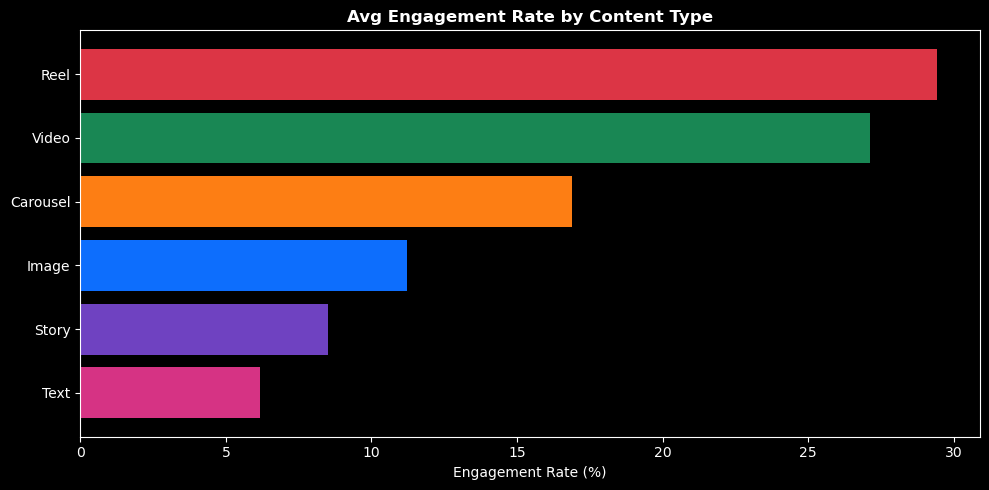

In [14]:
content_perf = df.groupby('content_type')['engagement_rate'].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(content_perf.index, content_perf.values, color=colors)
ax.set_title('Avg Engagement Rate by Content Type', fontweight='bold')
ax.set_xlabel('Engagement Rate (%)')
plt.tight_layout()
plt.savefig('charts/02_content_type.png', dpi=150)
plt.show()

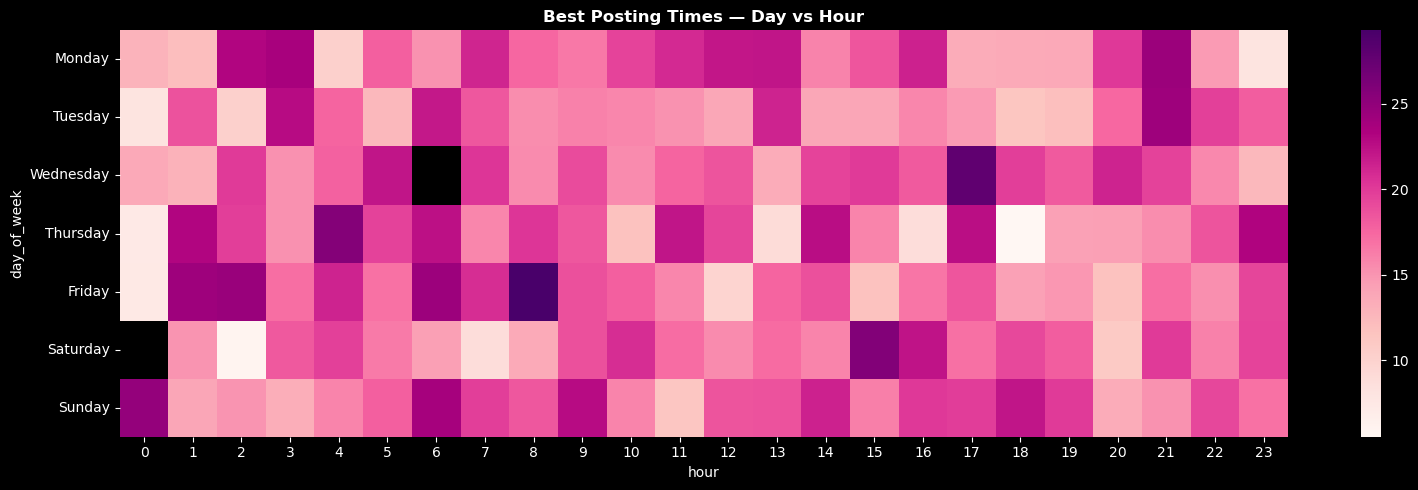

In [15]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
heatmap_data = df.pivot_table(
    values='engagement_rate', index='day_of_week',
    columns='hour', aggfunc='mean').reindex(day_order)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(heatmap_data, cmap='RdPu', ax=ax)
ax.set_title('Best Posting Times — Day vs Hour', fontweight='bold')
plt.tight_layout()
plt.savefig('charts/03_heatmap.png', dpi=150)
plt.show()

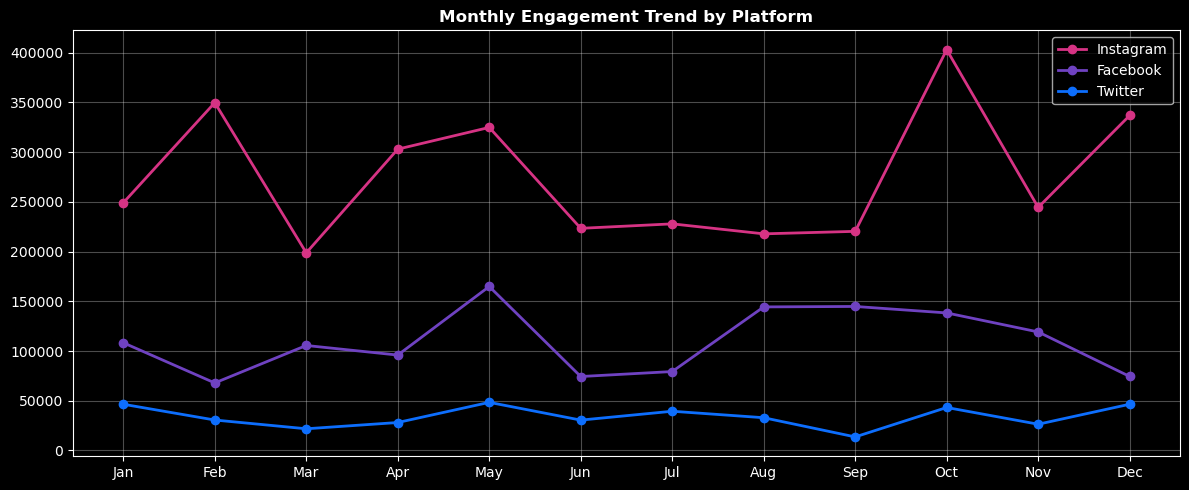

In [16]:
monthly = df.groupby(['month', 'platform'])['total_engagement'].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
for i, plat in enumerate(['Instagram', 'Facebook', 'Twitter']):
    d = monthly[monthly['platform'] == plat]
    ax.plot(d['month'], d['total_engagement'], marker='o', 
            color=colors[i], linewidth=2, label=plat)

ax.set_title('Monthly Engagement Trend by Platform', fontweight='bold')
ax.set_xticks(range(1,13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'])
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('charts/04_monthly_trend.png', dpi=150)
plt.show()

In [17]:
print("=== KEY INSIGHTS ===")
print("Best Platform :", df.groupby('platform')['engagement_rate'].mean().idxmax())
print("Best Content  :", df.groupby('content_type')['engagement_rate'].mean().idxmax())
print("Best Day      :", df.groupby('day_of_week')['engagement_rate'].mean().idxmax())
print("Best Time Slot:", df.groupby('time_slot')['engagement_rate'].mean().idxmax())
print("Avg ER        :", round(df['engagement_rate'].mean(), 2), "%")

=== KEY INSIGHTS ===
Best Platform : Instagram
Best Content  : Reel
Best Day      : Sunday
Best Time Slot: Morning (6-11)
Avg ER        : 17.47 %


In [18]:
import os
print(os.getcwd())

C:\Users\hp
